In [63]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm


from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [64]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


In [65]:
zoom = False

## Ocean Mask

In [66]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

# N

In [269]:
#all (Sw+lw) TOA; net and clear-sky. downward positive
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_n.nc'
n= xr.open_dataset(fp)

#change the longitude defintion to 0-360
n['longitude'] = (n['longitude']+360)%360
n = n.sortby('longitude')

#change the longitude defintion to 0-360
n = n.rename({'latitude':'lat', 'longitude':'lon'})
n = n.drop_vars(['number', 'expver'])

n = n.rename({'valid_time':'time'})


#over indo-pac only
n = n.where(ocean_mask)

In [270]:
#convert to w/m2
n = n/(60**2*24)

In [271]:
#make rolling mean
n = n.rolling(time = 3, center = True, min_periods = 1).mean()

In [272]:
weights = np.cos(np.deg2rad(n.lat))

In [273]:
#total short and longwave
n['n'] = n.tsr+n.ttr

In [274]:
# Calculate climatology (1990-2020)
n['n_clim'] = n.sel(time=slice('1991-01-01', '2020-12-31')).groupby('time.month').mean('time').n

# Calculate anomalies
n['n_anom'] = n.n.groupby('time.month') - n.n_clim

In [290]:
y = 2023
sel1 = n.sel(time = str(y)).where((n.time.dt.month<=9)&(n.time.dt.month>=4)).mean('time')
sel2 = n.sel(time = str(y-1)).where((n.time.dt.month<=9)&(n.time.dt.month>=4)).mean('time')

delta_n23 = sel1-sel2

In [291]:
compound_years = [1982, 1987, 1991, 1997, 2015]

#select year  april to sepember
n_sel1 = n.where((n.time.dt.year.isin(compound_years)) & (n.time.dt.month <= 9) &(n.time.dt.month>=4))
n_sel1 = n_sel1.mean('time')

#select year -1
n_sel2 = n.where((n.time.dt.year.isin([y-1 for y in compound_years])) & (n.time.dt.month <= 9)&(n.time.dt.month>=4))
n_sel2 = n_sel2.mean('time')


#compute delta
delta_ncompound = n_sel1-n_sel2

In [292]:

#ApriltoSept
n_AS = n.where((n.time.dt.month <= 9)&(n.time.dt.month>=4), drop = True).n_anom
n_AS = n_AS.groupby('time.year').mean('time')


#take difference between years
diff_AS = n_AS# - n_AS.roll(year = 1)

#select compound years
diff_AS = diff_AS.where(diff_AS.year.isin(compound_years), drop = True)


In [293]:
delta_ndiff = delta_n23.n_anom - delta_ncompound

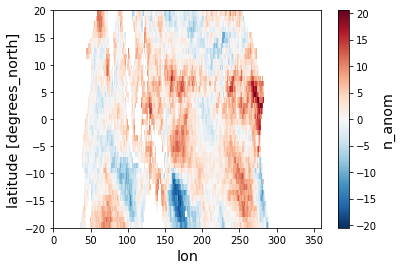

In [294]:
delta_ndiff.n_anom.plot()

In [295]:
change = delta_ndiff.n_anom
a = delta_n23.n_anom
b = diff_AS

In [296]:
weights = np.cos(np.deg2rad(delta_n23.lat))
delta_n23.n_anom.weighted(weights).mean()


<xarray.DataArray 'n_anom' ()>
array(1.62215695)

In [297]:
weights = np.cos(np.deg2rad(delta_ncompound.lat))
diff_AS.weighted(weights).mean()


<xarray.DataArray 'n_anom' ()>
array(0.27689284)

In [298]:
deltas = []
weights = np.cos(np.deg2rad(delta_ncompound.lat))
for cy in diff_AS:
    deltas.append(cy.weighted(weights).mean().values)
deltas

[array(-0.48318294),
 array(0.83116167),
 array(-0.56070335),
 array(0.86224127),
 array(0.73494757)]

In [299]:
print(np.mean(deltas))
print(np.std(deltas))

0.2768928440936391
0.6540555683528669


In [300]:
comparision = a>b

In [301]:
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=4

/tmp/ipykernel_831366/4236552225.py:81: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([round(a) for a in ax.get_xticks()], fontsize=20)


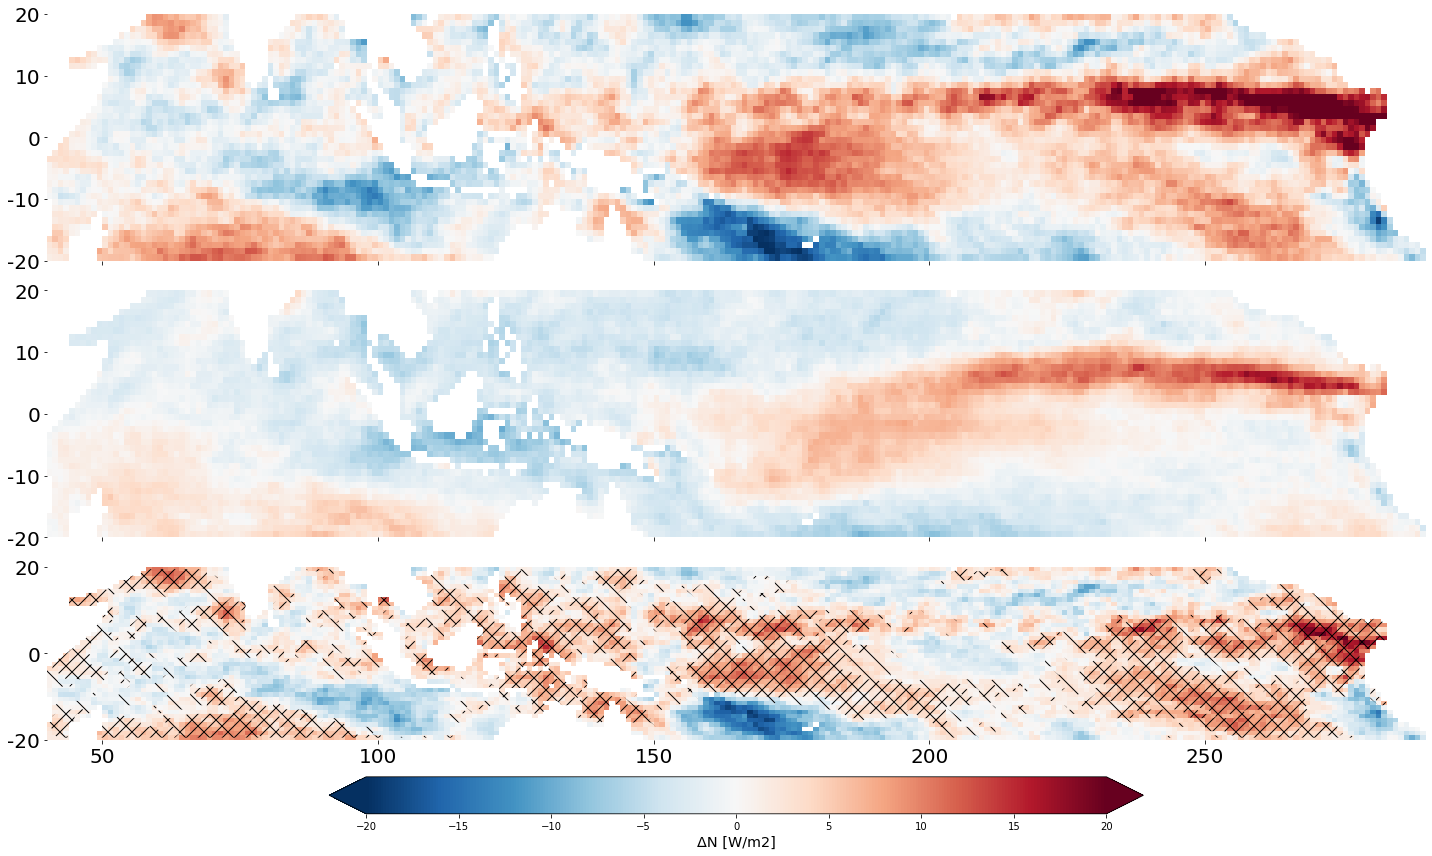

In [302]:
fig, axes = plt.subplots(3,1, figsize = (20,12), sharex = True)


# Define boundaries for discrete levels
bounds = np.linspace(-20,20 , 11)  # 10 discrete intervals between -20 and 20
norm = BoundaryNorm(boundaries=bounds, ncolors=10)

norm = mcolors.Normalize(vmin = -20, vmax = 20)

# Apply the colormap with the BoundaryNorm
cbar = delta_n23.n_anom.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[0], 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[0], label = 'N Change [W/m2]')


axes[0].set_ylabel('Latitude')
axes[0].set_xlabel('')

#-----------------------------
# Apply the colormap with the BoundaryNorm
cbar = delta_ncompound.n_anom.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[1], 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[1], label = 'N Change [W/m2]')


axes[1].set_ylabel('Latitude')
axes[1].set_xlabel('')



#-----------------------------
# Apply the colormap with the BoundaryNorm
cbar = delta_ndiff.n_anom.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[2], 
    add_colorbar=False
)
fig.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')




#------------------significance masking

# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

for ax in axes: 
    ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    ax.set_yticklabels([round(a) for a in ax.get_yticks()], fontsize=20)
    ax.set_xticklabels([round(a) for a in ax.get_xticks()], fontsize=20)
    
    ax.spines[:].set_visible(False)

plt.tight_layout()

In [288]:
weights = np.cos(np.deg2rad(n.lat))

n_oceanmean = n.sel(time = slice('1979', '2024')).n_anom.weighted(weights).mean(['lat', 'lon'])

/tmp/ipykernel_831366/2433500701.py:1: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')


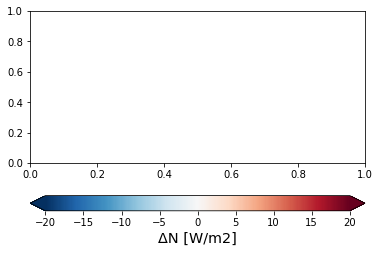

In [289]:
plt.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')


# SST change

In [238]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20))#,lon= slice(110, 260))

w500 = w500.where(ocean_mask)


In [239]:
w500 = w500.where((w500.time.dt.month<=9)& (w500.time.dt.month>=4)).groupby('time.year').mean('time')
w2023 = w500.sel(year = 2023)
wcompound = w500.where(w500.year.isin(compound_years+[2023]), drop = True).mean('year')
wdiff = w500.where(w500.year.isin(compound_years), drop = True).mean('year')


In [240]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(20,-20)).where(ocean_mask)



In [243]:
sst_clim = sst.groupby('time.month').mean()

sst['anom'] =sst.sst.groupby('time.month') - sst_clim.sst

In [244]:
weights = np.cos(np.deg2rad(sst.lat))

#yearly average Jan-Sept
sst_y = sst.where((sst.time.dt.month<=9) & (sst.time.dt.month>=4)).groupby('time.year').mean()

#change in sst_y
d_sst = sst_y - sst_y.roll(year = 1)


In [245]:
d_2023 = d_sst.sel(year = 2023)


In [246]:
d_compound = d_sst.where(d_sst.year.isin(compound_years), drop = True)

In [247]:
diff = d_2023-d_compound.mean('year')


## mask to check comparision

In [248]:
comparision = d_2023.sst>d_compound.sst
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

/tmp/ipykernel_831366/2415339679.py:65: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([round(a) for a in ax.get_xticks()], fontsize=20)


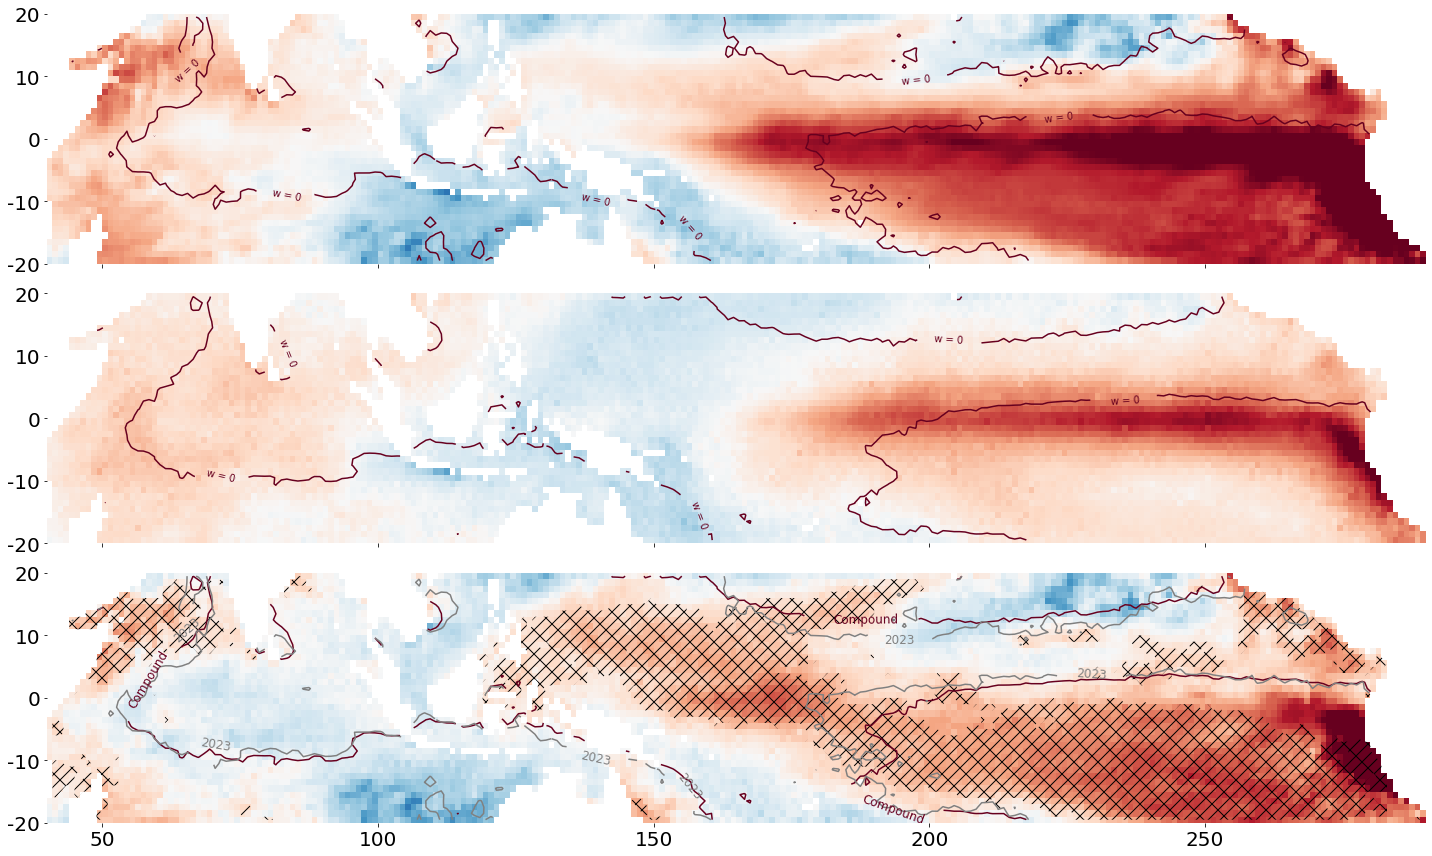

In [249]:
fig, axes = plt.subplots(3,1, figsize = (20,12), sharex = True)


cbar = d_2023.anom.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2, ax = axes[0], add_colorbar = False)

# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0])


axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=10)

#-----------------------------


cbar = d_compound.mean('year').anom.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2,add_colorbar = False, ax = axes[1])

# Plot the contour
CS1 = wcompound.w.plot.contour(levels=[-0.0], ax=axes[1])


axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=10)

#---------------------
cbar = diff.anom.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2, add_colorbar = False)#label=r'$\Delta anom [K]$')

# Plot the contour
CS1 = wcompound.w.plot.contour(levels=[-0.0], ax=axes[2])
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'grey')


axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'Compound'}, fontsize=12);
axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);


#------------------significance masking

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

for ax in axes: 
    ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    ax.set_yticks(ax.get_yticks()[::2])
    ax.set_yticklabels([round(a) for a in ax.get_yticks()], fontsize=20)
    ax.set_xticklabels([round(a) for a in ax.get_xticks()], fontsize=20)
    
    ax.spines[:].set_visible(False)

plt.tight_layout()

/tmp/ipykernel_3909778/2090949014.py:2: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, extend = 'both', label = 'ΔSST [K]')


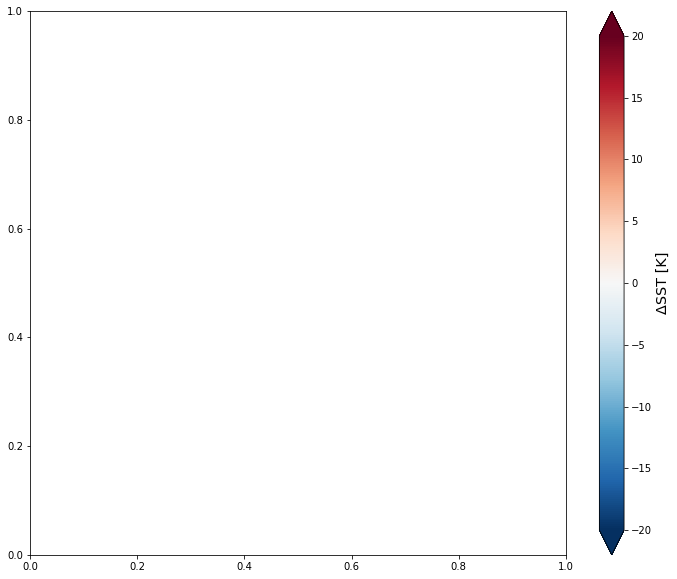

In [133]:
plt.figure(figsize = (12,10))
plt.colorbar(cbar, extend = 'both', label = 'ΔSST [K]')

## CERES

In [150]:
fp = '/data/jmex/CERES/CERES_TOA.nc'
ceres = xr.open_dataset(fp).where(ocean_mask)

clim = ceres.sel(time = slice('1991', '2020')).groupby('time.month').mean()
ceres_anom = ceres.groupby('time.month') - clim
ceres_anom = ceres_anom.rolling(time = 3, center = True, min_periods = 1).mean()

In [172]:
y = 2023
sel1 = ceres_anom.sel(time = str(y)).where((ceres_anom.time.dt.month<=9)&(ceres_anom.time.dt.month>=4)).mean('time')
sel2 = ceres_anom.sel(time = str(y-1)).where((ceres_anom.time.dt.month<=9)&(ceres_anom.time.dt.month>=4)).mean('time')

delta_ceres = sel1#-sel2

/tmp/ipykernel_831366/2044126911.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([round(a) for a in ax.get_xticks()], fontsize=20)


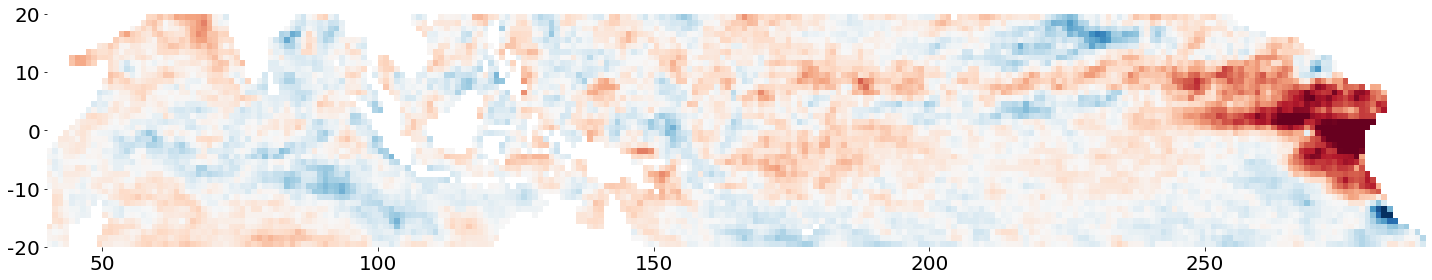

In [173]:
fig, ax = plt.subplots(1,1, figsize = (20,4))


norm = mcolors.Normalize(vmin = -20, vmax = 20)

# Apply the colormap with the BoundaryNorm
cbar = delta_ceres.toa_net_all_mon.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=ax, 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[0], label = 'N Change [W/m2]')


#fig.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')

for ax in [ax]:
    ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    ax.set_yticklabels([round(a) for a in ax.get_yticks()], fontsize=20)
    ax.set_xticklabels([round(a) for a in ax.get_xticks()], fontsize=20)

    ax.spines[:].set_visible(False)

plt.tight_layout()

/tmp/ipykernel_831366/1129287100.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([round(a) for a in ax.get_xticks()], fontsize=20)


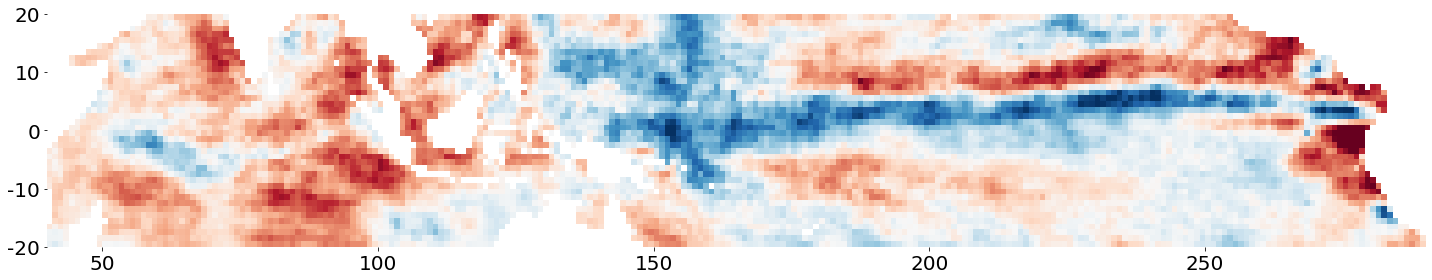

In [174]:
fig, ax = plt.subplots(1,1, figsize = (20,4))


norm = mcolors.Normalize(vmin = -20, vmax = 20)

# Apply the colormap with the BoundaryNorm
cbar = (-delta_ceres.toa_sw_all_mon).plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=ax, 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[0], label = 'N Change [W/m2]')


#fig.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')

for ax in [ax]:
    ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    ax.set_yticklabels([round(a) for a in ax.get_yticks()], fontsize=20)
    ax.set_xticklabels([round(a) for a in ax.get_xticks()], fontsize=20)

    ax.spines[:].set_visible(False)

plt.tight_layout()

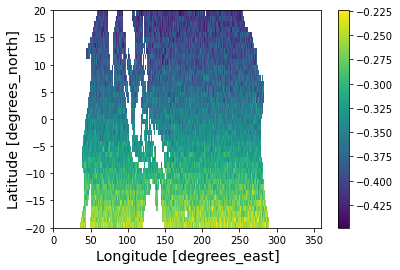

In [175]:
((-delta_ceres.toa_sw_all_mon-
delta_ceres.toa_lw_all_mon)-
delta_ceres.toa_net_all_mon).plot()


/tmp/ipykernel_3909778/1132306443.py:1: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')


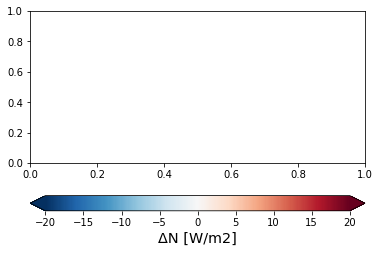

In [132]:
plt.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')



/tmp/ipykernel_3909778/1450473756.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([round(a) for a in ax.get_xticks()], fontsize=20)


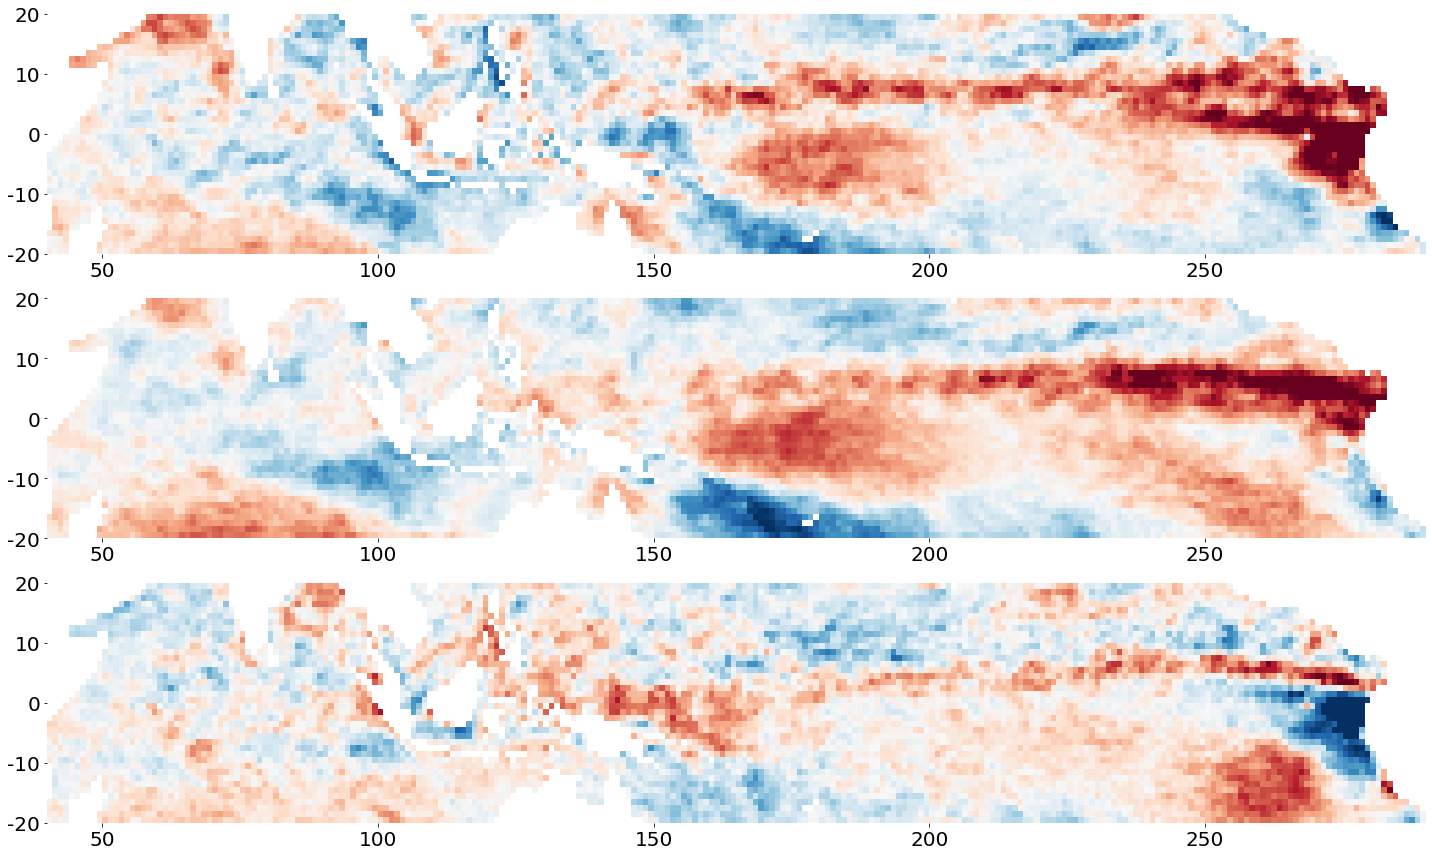

In [127]:
# comparing ceres and Era5

fig, [ax, ax2, ax3] = plt.subplots(3,1, figsize = (20,12))


norm = mcolors.Normalize(vmin = -20, vmax = 20)

# Apply the colormap with the BoundaryNorm
cbar = delta_ceres.toa_net_all_mon.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=ax, 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[0], label = 'N Change [W/m2]')


#fig.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')

# Apply the colormap with the BoundaryNorm
cbar = delta_n23.n.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=ax2, 
    add_colorbar=False
)


# Apply the colormap with the BoundaryNorm
cbar = (-delta_ceres.toa_net_all_mon + delta_n23.n).plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=ax3, 
    add_colorbar=False
)

for ax in [ax, ax2, ax3]:
    ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    ax.set_yticklabels([round(a) for a in ax.get_yticks()], fontsize=20)
    ax.set_xticklabels([round(a) for a in ax.get_xticks()], fontsize=20)

    ax.spines[:].set_visible(False)

plt.tight_layout()

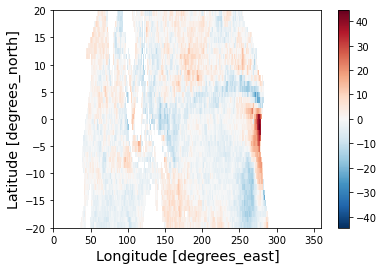

In [125]:
(delta_ceres.toa_net_all_mon - delta_n23.n).plot()

In [122]:
delta_ceres.toa_net_all_mon

<xarray.DataArray 'toa_net_all_mon' (lat: 40, lon: 360)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lon      (lon) float32 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * lat      (lat) float32 -19.5 -18.5 -17.5 -16.5 -15.5 ... 16.5 17.5 18.5 19.5

In [123]:
delta_n23.n

<xarray.DataArray 'n' (lat: 40, lon: 360)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 19.5 18.5 17.5 16.5 15.5 ... -16.5 -17.5 -18.5 -19.5
  * lon      (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5

In [124]:
n

<xarray.Dataset>
Dimensions:  (lat: 40, lon: 360, time: 1018, month: 12)
Coordinates:
  * lat      (lat) float64 19.5 18.5 17.5 16.5 15.5 ... -16.5 -17.5 -18.5 -19.5
  * lon      (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * time     (time) datetime64[ns] 1940-01-01T06:00:00 ... 2024-10-01T06:00:00
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    tsr      (time, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    ttr      (time, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    n        (time, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    n_clim   (month, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    n_anom   (time, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [212]:
#import sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1979', '2024'))

In [213]:
sst_aso = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [214]:
# compute nino34 for aso 
nino34 = sst_aso.sel(lat = slice(15, -15), lon = slice(190, 240))
nino34 = nino34 - nino34.sel(year = slice('1991', '2020')).mean('year')
nino34 = nino34.weighted(np.cos(np.deg2rad(nino34.lat))).mean(['lat', 'lon'])


## Clouds


In [215]:
fp  = '/data/jmex/ERA5/monthly/clouds/era5_clouds.nc'
clouds = xr.open_dataset(fp).sel(latitude = slice(20, -20), valid_time = slice('1979', '2024-10'))

In [216]:
clouds = clouds.drop(['expver', 'number'])
clouds = clouds.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
clouds['lon'] = (clouds['lon']+360)%360

clouds = clouds.where(ocean_mask)

In [217]:
#cmmpute means
weights = np.cos(np.deg2rad(clouds.lat))
clouds_mean = clouds.weighted(weights).mean(['lat', 'lon']) 
clouds_mean['ratio_l_h'] = clouds_mean.lcc/clouds_mean.hcc

In [218]:
clim = clouds_mean.sel(time = slice('1991', '2020')).groupby('time.month').mean()
clouds_anom = clouds_mean.groupby('time.month')-clim

In [219]:
clouds_anom = clouds_anom.rolling(time = 6, center = True, min_periods = 3).mean()

In [220]:
clouds_aso = clouds_anom.where(clouds_anom.time.dt.month.isin([8,9,10]), drop = True).groupby('time.year').mean()

In [221]:
nino34 = sst.sel(lat = slice(15, -15), lon = slice(190, 240))
nino34 = nino34.groupby('time.month') - nino34.groupby('time.month').mean()
nino34 = nino34.weighted(np.cos(np.deg2rad(nino34.lat))).mean(['lat', 'lon'])


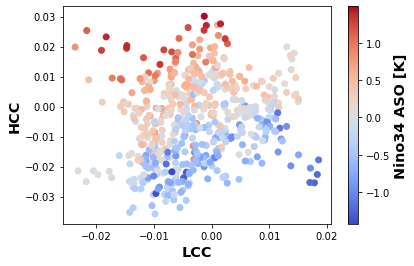

In [222]:
a = clouds_anom.sel(time = slice(None, '2023')).lcc
b = clouds_anom.sel(time = slice(None, '2023')).hcc
plt.scatter(a.roll(time = 7) ,b.roll(time = 0) , c = nino34.sel(time = slice(None, '2023')).sst.values, cmap = 'coolwarm')
plt.xlabel('LCC')
plt.ylabel('HCC')
plt.colorbar(label = 'Nino34 ASO [K]')

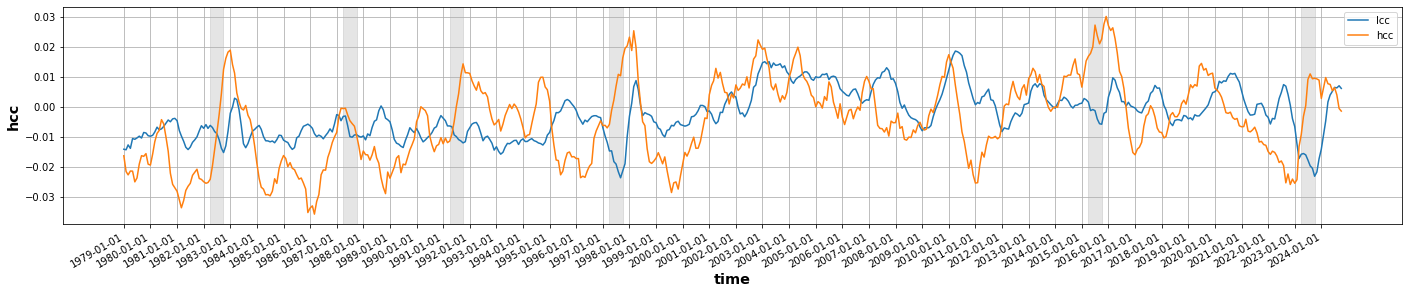

In [223]:
clouds_anom.lcc.plot(size= 4, aspect = 6,label = 'lcc' )

clouds_anom.hcc.plot(label = 'hcc')


# Fill the regions for the specified years
for year in compound_years+['2023']:
    start = np.datetime64(f"{year}-04-01")
    end = np.datetime64(f"{year}-09-30")
    plt.axvspan(start, end, color='gray', alpha=0.2)
    

plt.xticks(clouds_anom.time[::12]);
plt.grid()
plt.legend();

In [224]:
clouds_anom

<xarray.Dataset>
Dimensions:    (time: 550)
Coordinates:
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2024-10-01
    month      (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 12 1 2 3 4 5 6 7 8 9 10
Data variables:
    tcc        (time) float64 -0.02676 -0.03066 -0.02996 ... 0.01018 0.009363
    lcc        (time) float64 -0.01413 -0.01432 -0.0127 ... 0.007008 0.006124
    mcc        (time) float64 -0.0181 -0.01807 -0.01744 ... -0.004519 -0.002916
    hcc        (time) float64 -0.01632 -0.02157 -0.02269 ... -0.0005634 -0.00144
    ratio_l_h  (time) float64 -0.009899 -0.001638 0.004744 ... 0.01759 0.01705

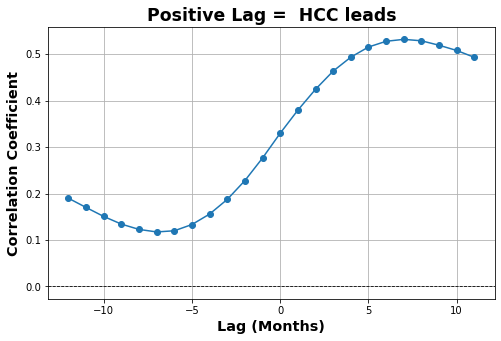

In [225]:
lcc = clouds_anom['lcc']
hcc = clouds_anom['hcc']

# Define the range of lags
lags = range(-12, 12)


# Compute lag correlations
correlations = []
for lag in lags:
    # Shift hcc relative to lcc for both positive and negative lags
    shifted_hcc = hcc.shift(time=lag)
    
    # Compute correlation
    corr = xr.corr(lcc, shifted_hcc, dim="time")
    correlations.append(corr.values)

# Plot the lag correlation
plt.figure(figsize=(8, 5))
plt.plot(lags, correlations, marker='o')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Positive Lag =  HCC leads')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation Coefficient')
plt.grid()
plt.show()

# LTS

In [226]:
fp = '/data/jmex/CERES/CERES_TOA.nc'
ceres = xr.open_dataset(fp).where(ocean_mask)

clim = ceres.sel(time = slice('1991', '2020')).groupby('time.month').mean()
ceres_anom = ceres.groupby('time.month') - clim

In [227]:
weights = np.cos(np.deg2rad(ceres_anom.lat))
ceres_ocean_anom = ceres_anom.weighted(weights).mean(['lat', 'lon'])
ceres_ocean_anom = ceres_ocean_anom.rolling(time = 6, center = True, min_periods = 1).mean()

In [228]:
#all (Sw+lw) TOA; net and clear-sky. downward positive
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_n.nc'
n= xr.open_dataset(fp)
#change the longitude defintion to 0-360
n['longitude'] = (n['longitude']+360)%360
n = n.sortby('longitude')

#change the longitude defintion to 0-360
n = n.rename({'latitude':'lat', 'longitude':'lon'})
n = n.drop_vars(['number', 'expver'])

n = n.rename({'valid_time':'time'})


#over indo-pac only
n = n.where(ocean_mask)

In [229]:
#convert to w/m2
n = n/(60**2*24)

In [230]:
#make rolling mean
n = n.rolling(time = 6, center = True, min_periods = 1).mean().sel(time = slice('1979', '2024-03'))

In [231]:
weights = np.cos(np.deg2rad(n.lat))

In [232]:
#total short and longwave
n['n'] = n.tsr+n.ttr

In [233]:
# Calculate climatology (1990-2020)
n['n_clim'] = n.sel(time=slice('1991-01-01', '2020-12-31')).groupby('time.month').mean('time').n

# Calculate anomalies
n['n_anom'] = n.n.groupby('time.month') - n.n_clim

n['ocean_anom'] = n.n_anom.weighted(weights).mean(['lat', 'lon'])

In [234]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

In [235]:
# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)

In [236]:
fp = '/data/jmex/ERA5/monthly/temp_pressure/era5_t79.nc'
t1000 = xr.open_dataset(fp).sel(latitude = slice(20, -20), 
                           pressure_level = 1000,
                            valid_time = slice('1979', '2024-10')).drop(['pressure_level', 'expver', 'number'],)
t700 = xr.open_dataset(fp).sel(latitude = slice(20, -20), 
                           pressure_level = 700,
                              valid_time = slice('1979', '2024-10')).drop(['pressure_level', 'expver', 'number'])


#change the longitude defintion to 0-360
t700['longitude'] = (t700['longitude']+360)%360
t700 = t700.sortby('longitude')

#change the longitude defintion to 0-360
t1000['longitude'] = (t1000['longitude']+360)%360
t1000 = t1000.sortby('longitude')


In [237]:
t1000 = t1000.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'}).where(ocean_mask).where(subs)
t1000 = t1000.sel(lon = slice(200, None))

In [238]:
t700 = t700.rename({'latitude':'lat', 'longitude':'lon',  'valid_time':'time'}).where(ocean_mask).where(subs)
t700 = t700.sel(lon = slice(200, None))

In [239]:
t700['t'] = convert_to_potential_temperature(t700.t, p = 700)
t1000['t'] = convert_to_potential_temperature(t1000.t, p = 1000)

In [240]:
#weigthed mean 
weights = np.cos(np.deg2rad(t700.lat))
t700 = t700.weighted(weights).mean(['lat', 'lon'])
t1000 = t1000.weighted(weights).mean(['lat', 'lon'])

In [241]:
anom700 = t700.groupby('time.month')-t700.groupby('time.month').mean()
anom1000 = t1000.groupby('time.month')-t1000.groupby('time.month').mean()

In [242]:
LTS = t700-t1000
clim = LTS.sel(time = slice('1991', '2020')).groupby('time.month').mean()
LTS['anom'] = LTS.t.groupby('time.month') - clim.t

#running mean 
LTS = LTS.rolling(time = 6, center = True, min_periods = 3).mean()

In [243]:
def detrend(ds, var = 'anom'):
    # Assuming 'ds' is your xarray Dataset

    # Filter data to the time range 1991-2020
    time_mask = (ds['time'].dt.year >= 1991) & (ds['time'].dt.year <= 2020)

    # Extract time and anomaly values for the period 1991-2020
    time_values = ds['time'].where(time_mask, drop=True).values
    anom_values = ds[var].where(time_mask, drop=True).values

    # Convert time values to an index (e.g., number of years or months for fitting)
    time_in_index = np.arange(len(time_values))

    # Perform linear regression (time vs anomaly data) to find the trend for 1991-2020
    slope_anom, intercept_anom, _, _, _ = linregress(time_in_index, anom_values)

    # Calculate the trend for the entire time series, but only subtract the trend fitted from 1991-2020
    time_in_index_full = np.arange(len(ds['time'].values))  # Full time index

    # Calculate the trend based on the fitted slope and intercept
    trend_anom = slope_anom * time_in_index_full + intercept_anom

    # Subtract the linear trend from the 'anom' variable
    ds_detrended = ds.copy()
    ds_detrended[var] = ds[var] - trend_anom
    
    return ds_detrended



In [249]:
def detrend_short(ds, var = 'anom'):
    # Assuming 'ds' is your xarray Dataset

    # Filter data to the time range 2000-2020
    time_mask = (ds['time'].dt.year >= 2000) & (ds['time'].dt.year <= 2020)

    # Extract time and anomaly values for the period 1991-2020
    time_values = ds['time'].where(time_mask, drop=True).values
    anom_values = ds[var].where(time_mask, drop=True).values

    # Convert time values to an index (e.g., number of years or months for fitting)
    time_in_index = np.arange(len(time_values))

    # Perform linear regression (time vs anomaly data) to find the trend for 1991-2020
    slope_anom, intercept_anom, _, _, _ = linregress(time_in_index, anom_values)

    # Calculate the trend for the entire time series, but only subtract the trend fitted from 1991-2020
    time_in_index_full = np.arange(len(ds['time'].values))  # Full time index

    # Calculate the trend based on the fitted slope and intercept
    trend_anom = slope_anom * time_in_index_full + intercept_anom

    # Subtract the linear trend from the 'anom' variable
    ds_detrended = ds.copy()
    ds_detrended[var] = ds[var] - trend_anom
    
    return ds_detrended

LTS_detrended = detrend_short(LTS, 'anom')
clouds_anom_detrended = detrend_short(clouds_anom, var = 'lcc')
ceres_ocean_anom_detrended = detrend_short(ceres_ocean_anom, var = 'toa_net_all_mon')
n_detrended = detrend_short(n, var = 'ocean_anom')

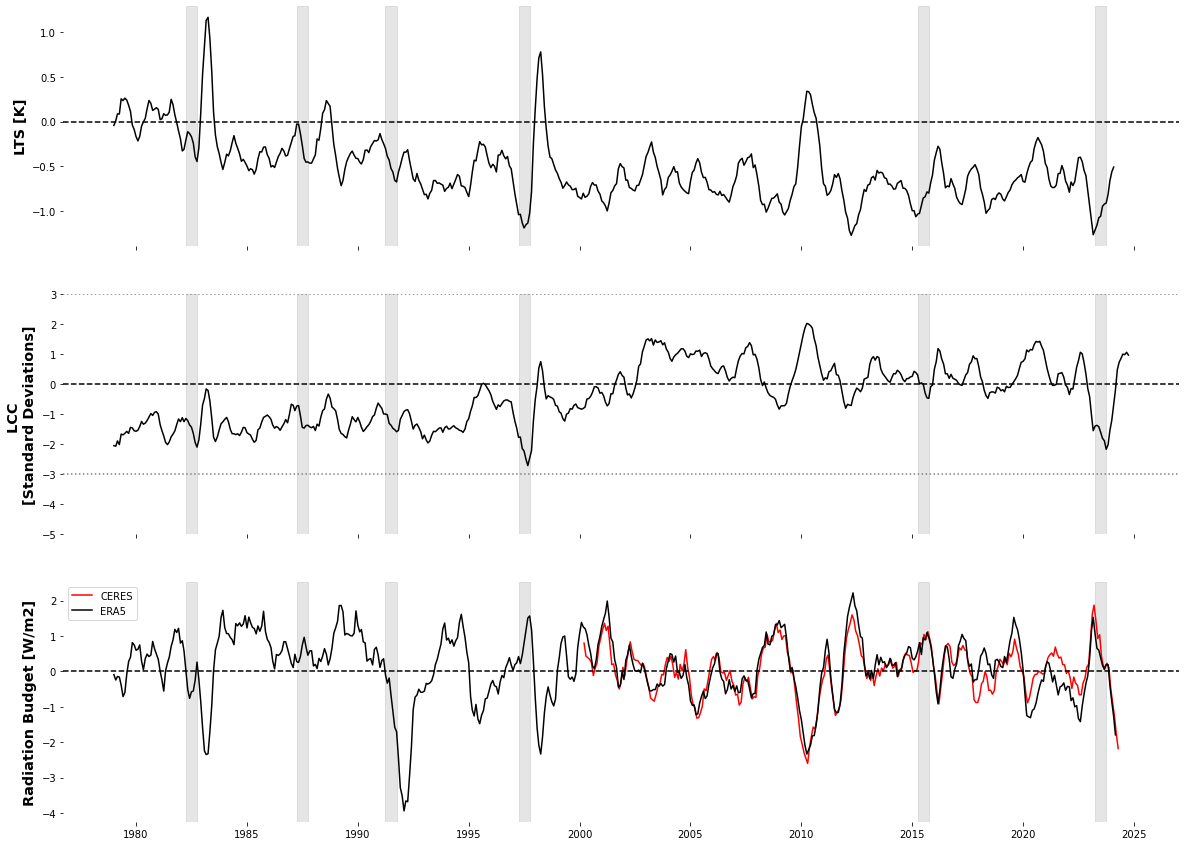

In [250]:
fig, axes = plt.subplots(3,1, figsize = (20,15), sharex = True)

axes[0].plot(LTS_detrended.time, LTS_detrended.anom.values, c = 'k')
axes[0].set_ylabel('LTS [K]')
#axes[0].axhline(0, c = 'k', linestyle = '-')


axes[1].plot(clouds_anom_detrended.time, clouds_anom_detrended.lcc/clouds_anom_detrended.lcc.std(), c = 'k')
#axes[1].axhline(0, linestyle = '-', c = 'k')
axes[1].axhline(3, linestyle = 'dotted', c = 'grey')
axes[1].axhline(-3, linestyle = 'dotted', c = 'grey')

axes[1].set_ylim(-5,3)

axes[1].set_ylabel('LCC \n[Standard Deviations]')


axes[2].plot(ceres_ocean_anom_detrended.time, ceres_ocean_anom_detrended.toa_net_all_mon, c = 'r', label = 'CERES')
axes[2].plot(n_detrended.time, n_detrended.ocean_anom, c = 'k', label = 'ERA5')
axes[2].set_ylabel('Radiation Budget [W/m2]')

# Fill the regions for the specified years
for year in compound_years+['2023']:
    start = np.datetime64(f"{year}-04-01")
    end = np.datetime64(f"{year}-09-30")
    axes[0].axvspan(start, end, color='gray', alpha=0.2)
    axes[1].axvspan(start, end, color='gray', alpha=0.2)
    axes[2].axvspan(start, end, color='gray', alpha=0.2)
    
    
for ax in axes:
    ax.axhline(0, c = 'k', linestyle = '--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.legend()

#plt.tight_layout()

In [246]:
L = LTS_detrended.t.sel(time = slice('2000-03', '2023'))

In [247]:
C = ceres_ocean_anom_detrended.toa_net_all_mon.sel(time = slice('2000', '2023'))

LinregressResult(slope=-0.5811529396731463, intercept=9.707334298885865, rvalue=-0.4011373735297065, pvalue=1.7568817630002913e-12, stderr=0.07874846669043044, intercept_stderr=1.3114528007001196)

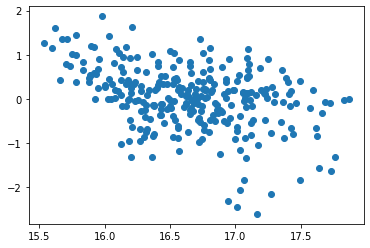

In [248]:
plt.scatter(L,C)
linregress(L,C)